In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

from imblearn.over_sampling import SMOTE

In [2]:
import warnings
warnings.filterwarnings("ignore")
sns.set(style = "whitegrid")

In [3]:
df = pd.read_csv("AIML Dataset.csv")

In [4]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 859186 entries, 0 to 859185
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   step            859186 non-null  int64  
 1   type            859186 non-null  object 
 2   amount          859186 non-null  float64
 3   nameOrig        859186 non-null  object 
 4   oldbalanceOrg   859186 non-null  float64
 5   newbalanceOrig  859186 non-null  float64
 6   nameDest        859186 non-null  object 
 7   oldbalanceDest  859186 non-null  float64
 8   newbalanceDest  859186 non-null  float64
 9   isFraud         859185 non-null  float64
 10  isFlaggedFraud  859185 non-null  float64
dtypes: float64(7), int64(1), object(3)
memory usage: 72.1+ MB


In [6]:
df.isnull().sum()

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,0
isFraud,1


In [7]:
df.dropna(inplace=True)

In [8]:
print(df.isnull().sum())

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


In [9]:
df["isFraud"] = df["isFraud"].astype(int)
df["isFlaggedFraud"] = df["isFlaggedFraud"].astype(int)

In [10]:
print(df[["isFraud", "isFlaggedFraud"]].dtypes)

isFraud           int64
isFlaggedFraud    int64
dtype: object


In [11]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [12]:
df["isFraud"].value_counts()

,count
isFraud,
0,858701
1,484


In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.shape

(859185, 11)

In [15]:
print(df["isFraud"].value_counts(normalize=True) * 100)

isFraud
0    99.943668
1     0.056332
Name: proportion, dtype: float64


Exploratory Data Analysis

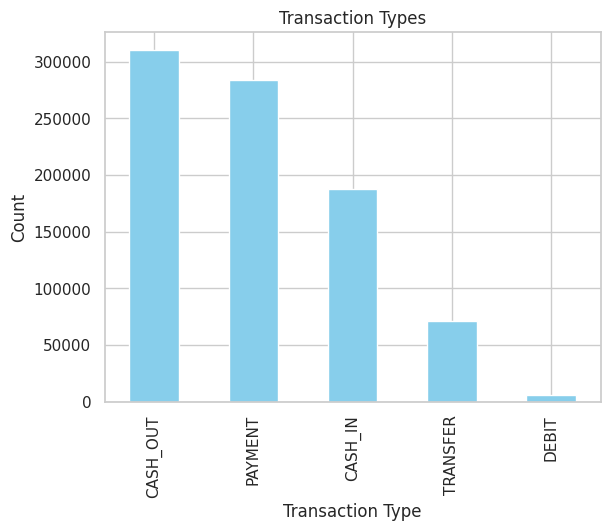

In [16]:
df["type"].value_counts().plot(kind="bar", title="Transaction Types", color="skyblue")
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.show()

In [17]:
fraud_by_type = df.groupby("type")["isFraud"].mean().sort_values(ascending=False)
print(fraud_by_type)

type
TRANSFER    0.003291
CASH_OUT    0.000805
CASH_IN     0.000000
DEBIT       0.000000
PAYMENT     0.000000
Name: isFraud, dtype: float64


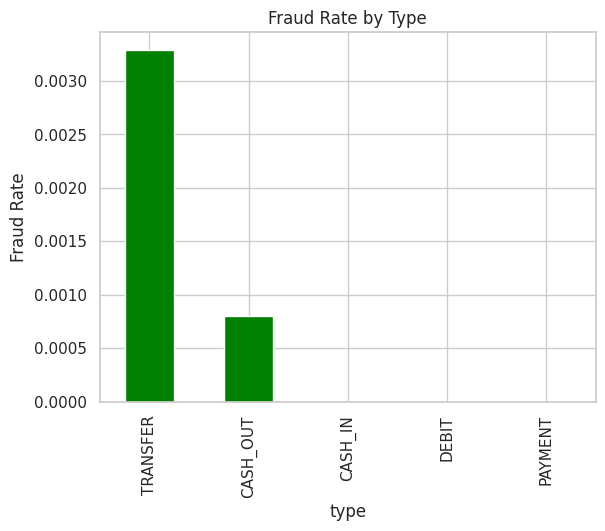

In [18]:
fraud_by_type.plot(kind="bar", title="Fraud Rate by Type", color="Green")
plt.ylabel("Fraud Rate")
plt.show()

In [19]:
df["amount"].describe().astype(int)

,amount
count,859185
mean,163692
std,264847
min,0
25%,13035
50%,80723
75%,221112
max,10000000


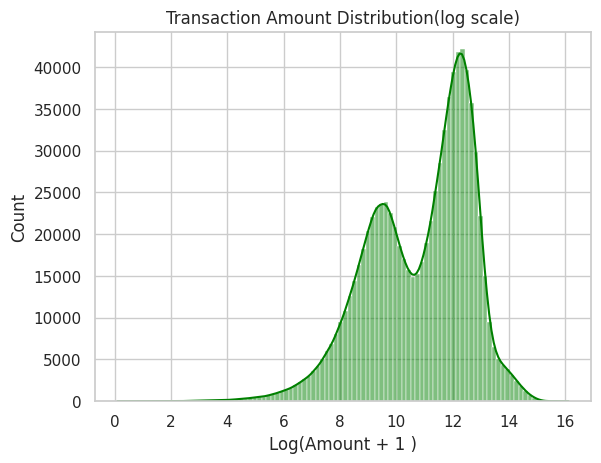

In [20]:
sns.histplot(np.log1p(df["amount"]), bins=100, kde = True, color = "green")
plt.title("Transaction Amount Distribution(log scale)")
plt.xlabel("Log(Amount + 1 )")
plt.show()

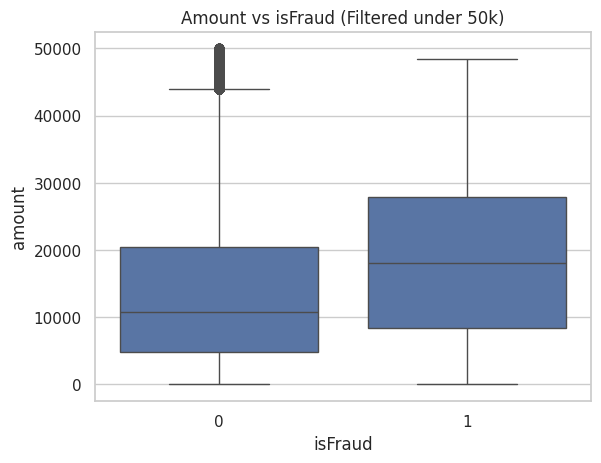

In [21]:
sns.boxplot(data=df[df["amount"]< 50000], x= "isFraud", y ="amount")
plt.title("Amount vs isFraud (Filtered under 50k)")
plt.show()

In [22]:
df["balanceDiffOrig"]= df["oldbalanceOrg"] - df["newbalanceOrig"]
df["balanceDiffDest"]= df["newbalanceDest"] - df["oldbalanceDest"]

In [23]:
(df["balanceDiffOrig"] < 0).sum()

np.int64(188070)

In [24]:
(df["balanceDiffDest"] < 0).sum()

np.int64(168928)

In [25]:
frauds_per_step = df[df["isFraud"] == 1]["step"].value_counts().sort_index()

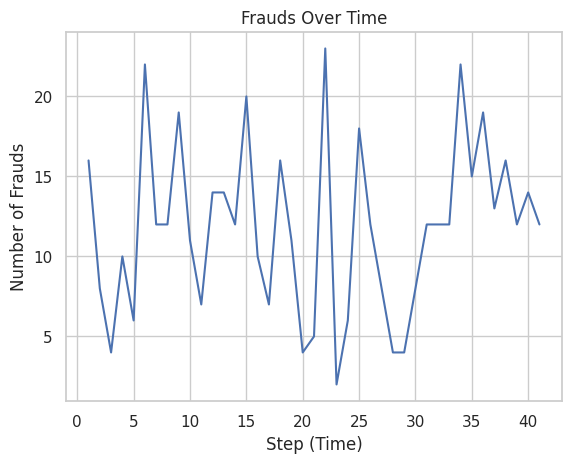

In [26]:
plt.plot(frauds_per_step.index, frauds_per_step.values, label ="Frauds per step")
plt.xlabel("Step (Time)")
plt.ylabel("Number of Frauds")
plt.title("Frauds Over Time")
plt.grid(True)
plt.show()

In [27]:
df.drop(columns ="step" , inplace=True)

In [28]:
df.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0
3,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,-21182.0
4,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0


In [29]:
top_senders = df["nameOrig"].value_counts().head(10)

In [30]:
top_senders

,count
nameOrig,
C1408814595,2
C1935167517,2
C275617751,2
C1162717140,2
C626611579,2
C1990399992,2
C213801919,2
C960373735,2
C1738972765,2


In [31]:
top_receivers = df["nameDest"].value_counts().head(10)

In [32]:
top_receivers

,count
nameDest,
C1286084959,96
C985934102,96
C248609774,88
C1590550415,87
C665576141,87
C2083562754,86
C1360767589,81
C977993101,80
C451111351,78


In [33]:
fraud_users = df[df["isFraud"]== 1]["nameOrig"].value_counts().head(10)

In [34]:
fraud_users

,count
nameOrig,
C866414395,1
C1305486145,1
C840083671,1
C1420196421,1
C418271713,1
C1551140519,1
C82669876,1
C1340596396,1
C1440649048,1


In [35]:
fraud_types = df[df["type"].isin(["TRANSFER", "CASH_OUT"])]

In [36]:
fraud_types["type"].value_counts()

,count
type,
CASH_OUT,310537
TRANSFER,71105


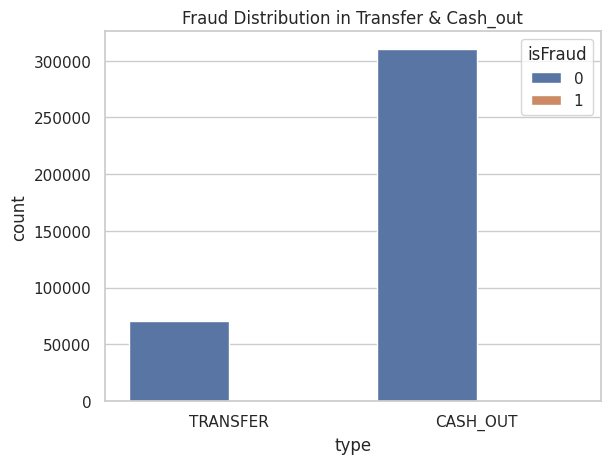

In [37]:
sns.countplot(data=fraud_types, x="type", hue="isFraud")
plt.title("Fraud Distribution in Transfer & Cash_out")
plt.show()

In [38]:
corr = df[["amount", "oldbalanceOrg", "newbalanceOrig",
           "oldbalanceDest", "newbalanceDest", "isFraud"]].corr()

In [39]:
corr

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
amount,1.000000,-0.005192,-0.007144,0.213558,0.312567,0.071269
oldbalanceOrg,-0.005192,1.000000,0.999215,0.092513,0.062855,0.000748
newbalanceOrig,-0.007144,0.999215,1.000000,0.094223,0.062512,-0.006849
oldbalanceDest,0.213558,0.092513,0.094223,1.000000,0.976172,-0.004833
newbalanceDest,0.312567,0.062855,0.062512,0.976172,1.000000,-0.000716
isFraud,0.071269,0.000748,-0.006849,-0.004833,-0.000716,1.000000


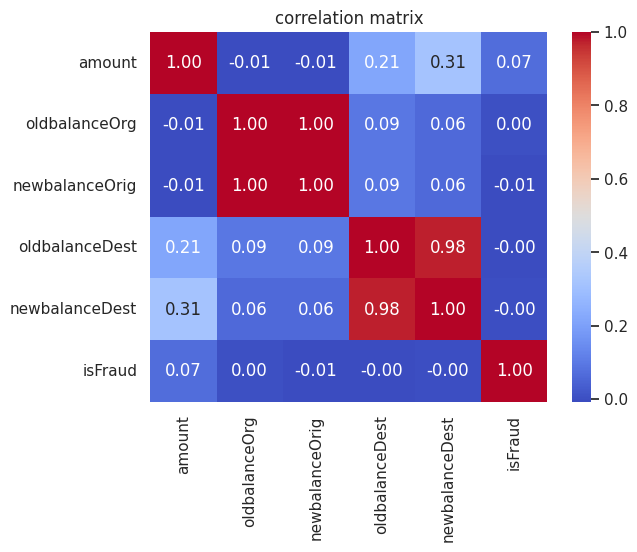

In [40]:
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("correlation matrix")
plt.show()

In [41]:
zero_after_transfer = df[
    (df["oldbalanceOrg"]> 0) &
    (df["newbalanceOrig"] == 0 )&
    (df["type"].isin(["TRANSFER", "CASH_OUT"]))
]

In [42]:
len(zero_after_transfer)

160495

In [43]:
zero_after_transfer.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
2,TRANSFER,181.00,C1305486145,181.0,0.0,C553264065,0.0,0.00,1,0,181.0,0.00
3,CASH_OUT,181.00,C840083671,181.0,0.0,C38997010,21182.0,0.00,1,0,181.0,-21182.00
15,CASH_OUT,229133.94,C905080434,15325.0,0.0,C476402209,5083.0,51513.44,0,0,15325.0,46430.44
19,TRANSFER,215310.30,C1670993182,705.0,0.0,C1100439041,22425.0,0.00,0,0,705.0,-22425.00
24,TRANSFER,311685.89,C1984094095,10835.0,0.0,C932583850,6267.0,2719172.89,0,0,10835.0,2712905.89


In [44]:
df["isFraud"].value_counts()

,count
isFraud,
0,858701
1,484


Feature Engineering

In [47]:
df_model = df.drop(["nameOrig", "nameDest"], axis=1)

In [48]:
df_model.head()

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0,0,9839.64,0.0
1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0,0,1864.28,0.0
2,TRANSFER,181.00,181.0,0.00,0.0,0.0,1,0,181.00,0.0
3,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1,0,181.00,-21182.0
4,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0,0,11668.14,0.0


In [49]:
categorical = ["type"]
numerical = ["amount", "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest","newbalanceDest"]

In [50]:
features = [
    "type",
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "isFlaggedFraud"
]

X = df[features]
y = df["isFraud"]

In [51]:
# y = df_model["isFraud"]
# X = df_model.drop("isFraud", axis = 1)

In [52]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, stratify=y)

In [55]:
print("Training:")
print(y_train.value_counts())

Training:
isFraud
0    601090
1       339
Name: count, dtype: int64


In [56]:
print("\nTesting:")
print(y_test.value_counts())


Testing:
isFraud
0    257611
1       145
Name: count, dtype: int64


In [57]:
preprocessor = ColumnTransformer(
    transformers =[
        ("num", StandardScaler(), numerical),
        ("cat", OneHotEncoder(drop="first",handle_unknown="ignore"), categorical)

    ],
    remainder = "drop"
)

In [58]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [59]:
print(X_train_processed.shape)
print(X_test_processed.shape)

(601429, 9)
(257756, 9)


In [61]:
smote = SMOTE(random_state=42)

In [62]:
X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

In [63]:
print("Before SMOTE:")
print(y_train.value_counts())

Before SMOTE:
isFraud
0    601090
1       339
Name: count, dtype: int64


In [64]:
print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())


After SMOTE:
isFraud
0    601090
1    601090
Name: count, dtype: int64


Logistic Regression

In [65]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [66]:
lr_model.fit(X_train_smote, y_train_smote)

LogisticRegression(max_iter=1000, random_state=42)

In [67]:
y_pred_lr = lr_model.predict(X_test_processed)

In [68]:
print("Logistic Regression + SMOTE")
print(classification_report(y_test, y_pred_lr))

Logistic Regression + SMOTE
              precision    recall  f1-score   support

           0       1.00      0.91      0.95    257611
           1       0.01      0.95      0.01       145

    accuracy                           0.91    257756
   macro avg       0.50      0.93      0.48    257756
weighted avg       1.00      0.91      0.95    257756



XG Boost

In [71]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

In [72]:
xgb_model.fit(
    X_train_smote,
    y_train_smote
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=-1,
              num_parallel_tree=None, ...)

In [73]:
y_pred_xgb = xgb_model.predict(X_test_processed)

In [74]:
print("XGBoost + SMOTE")
print(classification_report(y_test, y_pred_xgb))

XGBoost + SMOTE
              precision    recall  f1-score   support

           0       1.00      0.99      0.99    257611
           1       0.04      0.90      0.08       145

    accuracy                           0.99    257756
   macro avg       0.52      0.95      0.54    257756
weighted avg       1.00      0.99      0.99    257756



In [76]:
y_prob_xgb = xgb_model.predict_proba(
    X_test_processed
)[:, 1]

In [77]:
from sklearn.metrics import classification_report

for threshold in [0.1, 0.2, 0.3, 0.4, 0.5]:

    y_pred_threshold = (y_prob_xgb >= threshold).astype(int)

    print("\nThreshold:", threshold)
    print(classification_report(
        y_test,
        y_pred_threshold,
        digits=4
    ))


Threshold: 0.1
              precision    recall  f1-score   support

           0     1.0000    0.9693    0.9844    257611
           1     0.0173    0.9586    0.0339       145

    accuracy                         0.9693    257756
   macro avg     0.5086    0.9639    0.5091    257756
weighted avg     0.9994    0.9693    0.9839    257756


Threshold: 0.2
              precision    recall  f1-score   support

           0     1.0000    0.9782    0.9890    257611
           1     0.0237    0.9379    0.0462       145

    accuracy                         0.9782    257756
   macro avg     0.5118    0.9581    0.5176    257756
weighted avg     0.9994    0.9782    0.9884    257756


Threshold: 0.3
              precision    recall  f1-score   support

           0     1.0000    0.9829    0.9913    257611
           1     0.0297    0.9310    0.0576       145

    accuracy                         0.9829    257756
   macro avg     0.5148    0.9570    0.5245    257756
weighted avg     0.9994   

In [78]:
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np

thresholds = np.arange(0.01, 1.00, 0.01)

results_threshold = []

for threshold in thresholds:

    y_pred_threshold = (
        y_prob_xgb >= threshold
    ).astype(int)

    precision = precision_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    results_threshold.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

threshold_results_df = pd.DataFrame(results_threshold)

threshold_results_df.sort_values(
    by="F1",
    ascending=False
).head(10)

,Threshold,Precision,Recall,F1
98,0.99,0.798387,0.682759,0.736059
97,0.98,0.587571,0.717241,0.645963
96,0.97,0.478261,0.758621,0.586667
95,0.96,0.402827,0.786207,0.532710
94,0.95,0.342183,0.800000,0.479339
93,0.94,0.291045,0.806897,0.427788
92,0.93,0.251599,0.813793,0.384365
91,0.92,0.221805,0.813793,0.348597
90,0.91,0.201342,0.827586,0.323887
89,0.90,0.183183,0.841379,0.300863


In [79]:
# Final classification threshold
final_threshold = 0.99

In [80]:
y_prob_xgb = xgb_model.predict_proba(X_test_processed)[:, 1]

y_pred_final = (
    y_prob_xgb >= final_threshold
).astype(int)

In [81]:
from sklearn.metrics import classification_report

print("Final XGBoost Model - Threshold 0.99")

print(classification_report(
    y_test,
    y_pred_final,
    digits=4
))

Final XGBoost Model - Threshold 0.99
              precision    recall  f1-score   support

           0     0.9998    0.9999    0.9999    257611
           1     0.7984    0.6828    0.7361       145

    accuracy                         0.9997    257756
   macro avg     0.8991    0.8413    0.8680    257756
weighted avg     0.9997    0.9997    0.9997    257756



In [82]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred_final
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[257586     25]
 [    46     99]]


In [83]:
from sklearn.metrics import roc_auc_score, average_precision_score

roc_auc = roc_auc_score(
    y_test,
    y_prob_xgb
)

pr_auc = average_precision_score(
    y_test,
    y_prob_xgb
)

print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)

ROC-AUC: 0.9901982125147526
PR-AUC: 0.7592483713188152


SHAP

In [85]:
pip install shap

In [86]:
import shap

In [87]:
feature_names = preprocessor.get_feature_names_out()

print(feature_names)

['num__amount' 'num__oldbalanceOrg' 'num__newbalanceOrig'
 'num__oldbalanceDest' 'num__newbalanceDest' 'cat__type_CASH_OUT'
 'cat__type_DEBIT' 'cat__type_PAYMENT' 'cat__type_TRANSFER']


In [88]:
X_test_processed_df = pd.DataFrame(
    X_test_processed,
    columns=feature_names
)

In [89]:
X_test_processed_df.head()

,num__amount,num__oldbalanceOrg,num__newbalanceOrig,num__oldbalanceDest,num__newbalanceDest,cat__type_CASH_OUT,cat__type_DEBIT,cat__type_PAYMENT,cat__type_TRANSFER
0,0.722359,-0.295806,-0.299069,0.410201,0.471860,1.0,0.0,0.0,0.0
1,-0.617946,-0.269831,-0.273512,-0.426602,-0.464404,0.0,0.0,1.0,0.0
2,-0.526060,-0.288971,-0.299069,-0.426602,-0.464404,0.0,0.0,1.0,0.0
3,-0.185461,-0.293917,-0.259211,-0.217582,-0.313529,0.0,0.0,0.0,0.0
4,-0.572072,-0.295806,-0.299069,-0.426602,-0.464404,0.0,0.0,1.0,0.0


In [90]:
explainer = shap.TreeExplainer(xgb_model)

In [91]:
shap_values = explainer(
    X_test_processed_df
)

In [92]:
print(shap_values)

.values =
array([[-4.4821739e+00, -6.2898026e+00,  4.5885557e-01, ...,
         1.7691761e-03,  1.0365067e-01, -1.5165876e-01],
       [ 8.7722290e-01, -2.5671914e-01, -7.1581426e+00, ...,
         9.7634038e-03, -3.1655369e+00, -8.5143423e-01],
       [ 7.5935429e-01, -1.9798555e+00,  6.7196631e-01, ...,
         1.9353727e-03, -4.8317728e+00, -1.0422530e+00],
       ...,
       [-1.2045550e+00, -5.4264361e-01, -5.3941979e+00, ...,
         1.6624487e-03,  9.7011946e-02, -1.4905127e+00],
       [-1.0367713e+00, -6.4467955e+00,  4.3937671e-01, ...,
         1.5457666e-03, -2.8426309e+00, -6.9422817e-01],
       [ 1.2077219e-02, -5.9259677e+00,  4.7396570e-01, ...,
         1.7202625e-03, -3.2856674e+00, -6.5090322e-01]], dtype=float32)

.base_values =
array([-0.01244979, -0.01244979, -0.01244979, ..., -0.01244979,
       -0.01244979, -0.01244979], dtype=float32)

.data =
array([[ 0.72235928, -0.29580563, -0.29906925, ...,  0.        ,
         0.        ,  0.        ],
       [-0.61794

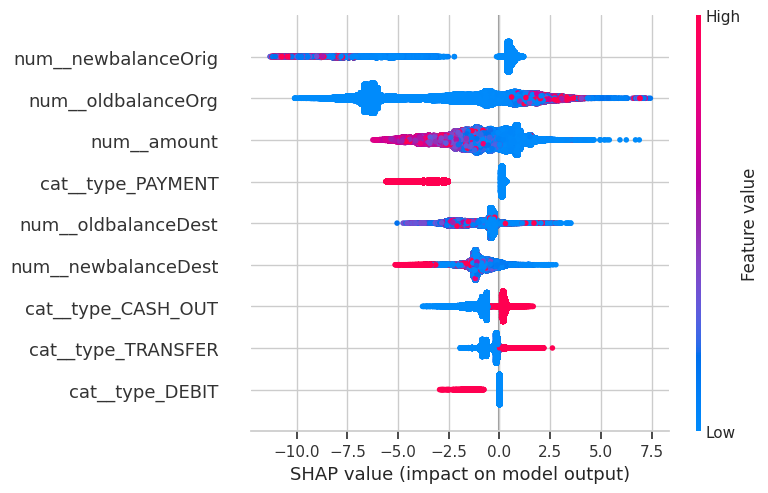

In [93]:
shap.summary_plot(
    shap_values,
    X_test_processed_df
)

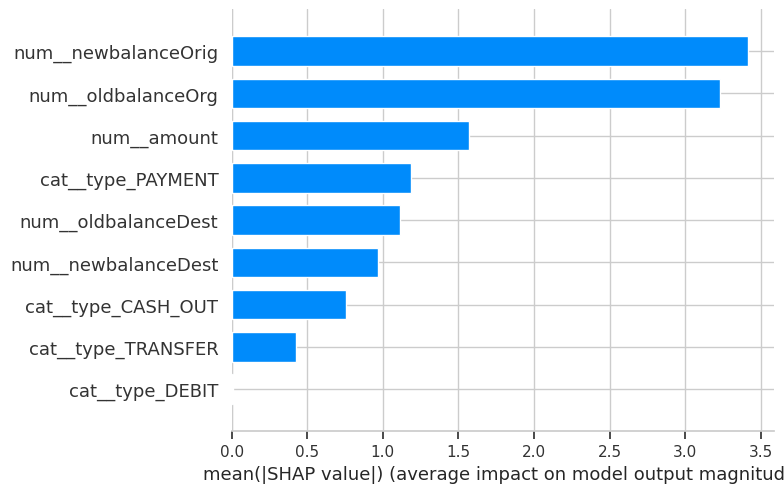

In [94]:
shap.summary_plot(
    shap_values,
    X_test_processed_df,
    plot_type="bar"
)

In [95]:
pip install joblib

In [96]:
import joblib

In [97]:
joblib.dump(
    xgb_model,
    "xgboost_fraud_model.pkl"
)

['xgboost_fraud_model.pkl']

In [98]:
joblib.dump(
    preprocessor,
    "fraud_preprocessor.pkl"
)

['fraud_preprocessor.pkl']

In [99]:
joblib.dump(
    final_threshold,
    "fraud_threshold.pkl"
)

['fraud_threshold.pkl']